# Deep Learning to reconstruct an image from its fMRI response

# Description:


 # Stage 1: Dataset
 (Dataset description) provenance, configuration

 Stimuli images can be be obtained thnaks to this link:

1. Folders and setup

In [1]:
#!pip install if dependencies not directly available

In [2]:
import os
import requests
from tqdm import tqdm
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
project = '/content/image_reconstruction'
fMRI = '/content/image_reconstruction/fMRI'
images = '/content/image_reconstruction/images'

for dir in [project,
          fMRI,
          images,
          os.path.join(images, 'training'),
          os.path.join(images, 'test')]:
    os.makedirs(dir, exist_ok=True)

print('Folders :')
print(f'  {project}')
print(f'  {fMRI}')
print(f'  {images}')

Folders :
  /content/image_reconstruction
  /content/image_reconstruction/fMRI
  /content/image_reconstruction/images


2. Download fMRI data


Subject1.mat is in HDF5 v7.3 format.
 It contains:

- dataSet with shape (4471, 3450) and float64 dtype.
- A metaData group containing:
  -  description dataset with shape (21, 1) and object dtype.
  - key dataset with shape (21, 1) and object dtype.
  - value dataset with shape (4471, 21) and float64 dtype.

Source : figshare via S3 AWS (URL obtained through https://github.com/KamitaniLab/GenericObjectDecoding)

In [4]:
MAT_URL  = 'https://s3-eu-west-1.amazonaws.com/pfigshare-u-files/13663487/Subject1.mat'
MAT_PATH = os.path.join(fMRI, 'Subject1.mat')

if os.path.exists(MAT_PATH):
    print(f'Subject1 already downloaded')
else:
    print('Downloading Subject1.mat...')
    r = requests.get(
        MAT_URL, stream=True,
        headers={'User-Agent': 'Mozilla/5.0'}
    )
    total = int(r.headers.get('content-length', 0))
    with open(MAT_PATH, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(8192):
            f.write(chunk)
            bar.update(len(chunk))
    print(f'\n Subject1 downloaded :{os.path.getsize(MAT_PATH)/1e6:.0f} MB')

100%|██████████| 120M/120M [00:04<00:00, 28.3MB/s]


 Subject1 downloaded :120 MB


3. Extract fMRI data

In [5]:
f = h5py.File(MAT_PATH, 'r')
data = f['dataSet'][:]
meta = f['metaData/value'][:]
key_refs = f['metaData/key'][:].flatten()
keys = [''.join(chr(c[0]) for c in f[ref][:]) for ref in key_refs]

print(f'dataSet shape  : {data.shape}')
print(f'metaData shape : {meta.shape}')
print(f'Columns in metaData  : {keys}')



dataSet shape  : (4471, 3450)
metaData shape : (4471, 21)
Columns inn metaData  : ['DataType', 'Run', 'Label', 'VoxelData', 'voxel_x', 'voxel_y', 'voxel_z', 'VolInds', 'ROI_V1', 'ROI_V2', 'ROI_V3', 'ROI_V4', 'ROI_LOC', 'ROI_FFA', 'ROI_PPA', 'ROI_LVC', 'ROI_HVC', 'ROI_VC', 'stimulus_id', 'category_index', 'image_index']


In [6]:
# data contains lines with voxels and lines with metadata
voxeldata_col = keys.index('VoxelData')
is_voxel = meta[:, voxeldata_col] == 1.0
is_other = ~is_voxel

print(f'True voxels     : {is_voxel.sum()}')
print(f'Metadata lines : {is_other.sum()}')

other_indices = np.where(is_other)[0]
for i in other_indices:
  row      = data[i, :]
  meta_row = meta[i, :]
  active   = [keys[k] for k in range(len(keys)) if meta_row[k] == 1.0]
  unique   = np.unique(row[~np.isnan(row)])
  print(f'  line {i}, meta={active}')

True voxels     : 4466
Metadata lines : 5
  line 0, meta=['DataType']
  line 1, meta=['Run']
  line 4468, meta=['Label', 'stimulus_id']
  line 4469, meta=['Label', 'category_index']
  line 4470, meta=['Label', 'image_index']


In [7]:
fmri_all = data[is_voxel, :].T.astype(np.float32)  # (3450, 4466)
datatype = data[0,    :].astype(int) # 1=train, 2=test, 3=imagery
run = data[1,    :].astype(int) # run number
image_index = data[4470, :] # index image

#test and train
mask_train = datatype == 1
mask_test = datatype == 2

fmri_train = fmri_all[mask_train]
fmri_test_raw = fmri_all[mask_test]
img_idx_train = image_index[mask_train]
img_idx_test = image_index[mask_test]

# for the test images, each image was seen 35 times
# so we can compute the average fMRI response for each image
unique_test_imgs = np.unique(img_idx_test[~np.isnan(img_idx_test)]).astype(int)
fmri_test = np.array([fmri_test_raw[img_idx_test == img].mean(axis=0) for img in unique_test_imgs])

print('Data :')
print(f'  fmri_train    : {fmri_train.shape} ({mask_train.sum()} trials)')
print(f'  fmri_test_raw : {fmri_test_raw.shape} ({mask_test.sum()} trials)')
print(f'  fmri_test     : {fmri_test.shape} (50 images x {35} averaged)')

Data :
  fmri_train    : (1200, 4466) (1200 trials)
  fmri_test_raw : (1750, 4466) (1750 trials)
  fmri_test     : (50, 4466) (50 images x 35 averaged)


In [8]:
# Extract ROI for later study
roi_names = ['ROI_V1', 'ROI_V2', 'ROI_V3', 'ROI_V4', 'ROI_LOC', 'ROI_FFA', 'ROI_PPA', 'ROI_LVC', 'ROI_HVC', 'ROI_VC']

roi_masks = {}
for roi in roi_names:
    if roi in keys:
        col_idx = keys.index(roi)
        mask = meta[is_voxel, col_idx] == 1.0
        roi_masks[roi] = mask
        print(f'  {roi:10s} : {mask.sum():} voxels')

  ROI_V1     : 1004 voxels
  ROI_V2     : 1018 voxels
  ROI_V3     : 759 voxels
  ROI_V4     : 740 voxels
  ROI_LOC    : 540 voxels
  ROI_FFA    : 568 voxels
  ROI_PPA    : 356 voxels
  ROI_LVC    : 2281 voxels
  ROI_HVC    : 2049 voxels
  ROI_VC     : 4466 voxels


4. Download stimulus

Due to copyright reasons on ImageNet, the images used as stimuli cannot be directly provided, but a zip file can be requested with the following form: https://forms.gle/ujvA34948Xg49jdn9

The following cell allows to download and unzip the folder from your google drive (easy when using google colab).

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, getpass

ZIP_PATH = '/content/drive/MyDrive/images_passwd.zip'

password = getpass.getpass('zip password : ')

EXTRACT_DIR = '/content/image_reconstruction'

print(f'Extraction of {ZIP_PATH}...')
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR, pwd=password.encode('utf-8'))
    print('Success')
except RuntimeError as e:
    print(f'Erreur : {e}')
    print('Verify password')

print('\nExtracted :')
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '  ' * level
    n = len(files)
    print(f'{indent}{os.path.basename(root)}/ ({n} files)')

Mounted at /content/drive
zip password : ··········
Extraction of /content/drive/MyDrive/images_passwd.zip...
Success

Extracted :
image_reconstruction/ (0 files)
  fMRI/ (1 files)
  images/ (2 files)
    test/ (50 files)
    training/ (1200 files)


In [10]:
test_dir = os.path.join(EXTRACT_DIR, 'images', 'test')
train_dir = os.path.join(EXTRACT_DIR, 'images', 'training')
test_id_csv = os.path.join(EXTRACT_DIR, 'images', 'image_test_id.csv')
train_id_csv = os.path.join(EXTRACT_DIR, 'images', 'image_training_id.csv')

ids_train = pd.read_csv(train_id_csv, header=None, names=['img_idx', 'filename'])
ids_test = pd.read_csv(test_id_csv,  header=None, names=['img_idx', 'filename'])

print(f'\nIDs train : {len(ids_train)}')
print(ids_train.head(3))
print(f'\nIDs test  : {len(ids_test)}')
print(ids_test.head(3))


IDs train : 1200
        img_idx              filename
0  1.518878e+06  n01518878_10042.JPEG
1  1.518878e+06  n01518878_12028.JPEG
2  1.518878e+06  n01518878_14075.JPEG

IDs test  : 50
        img_idx              filename
0  1.443537e+06  n01443537_22563.JPEG
1  1.621127e+06  n01621127_19020.JPEG
2  1.677366e+06  n01677366_18182.JPEG


5. Building the fMRI/image pairs

In [19]:
# image_index in the fMRI = position in the CSV

train_idx_to_path = {}
for i, row in ids_train.iterrows():
    position = i + 1
    filename = str(row['filename']).strip()
    path = os.path.join(train_dir, filename)
    if os.path.exists(path):
        train_idx_to_path[position] = path

test_idx_to_path = {}
for i, row in ids_test.iterrows():
    position = i + 1
    filename = str(row['filename']).strip()
    path = os.path.join(test_dir, filename)
    if os.path.exists(path):
        test_idx_to_path[position] = path

print(f'Train : {len(train_idx_to_path)}/1200')
print(f'Test  : {len(test_idx_to_path)}/50')

Train : 1200/1200
Test  : 50/50


In [31]:
def build_pairs(fmri_data, img_indices, idx_to_path):
    pairs = []
    for trial_idx, img_pos in enumerate(img_indices):
        img_pos = int(img_pos)
        if img_pos in idx_to_path:
            pairs.append({'trial_idx': trial_idx, 'img_pos': img_pos,'fmri': fmri_data[trial_idx],'img_path': idx_to_path[img_pos],})
    return pairs

pairs_train = build_pairs(fmri_train, img_idx_train, train_idx_to_path)
pairs_test  = build_pairs(fmri_test,  unique_test_imgs, test_idx_to_path)

print(f'Built pairs :')
print(f'  Train : {len(pairs_train)}')
print(f'  Test  : {len(pairs_test)}')

Built pairs :
  Train : 1200
  Test  : 50


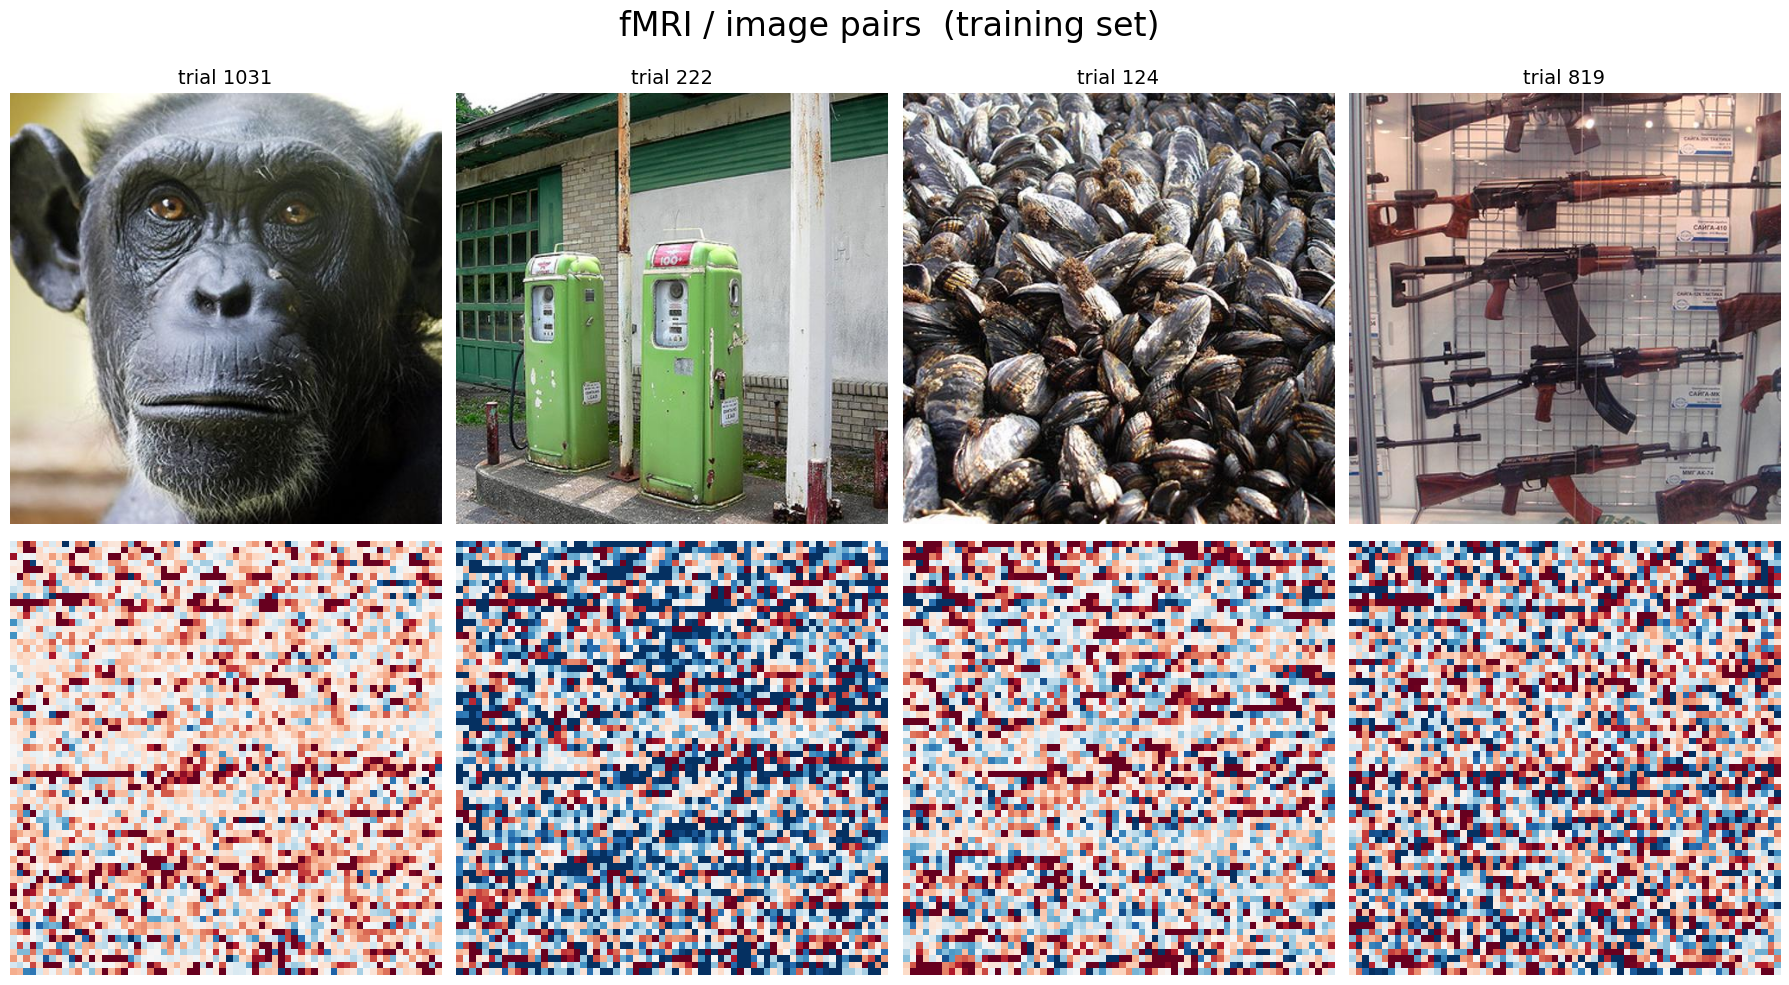

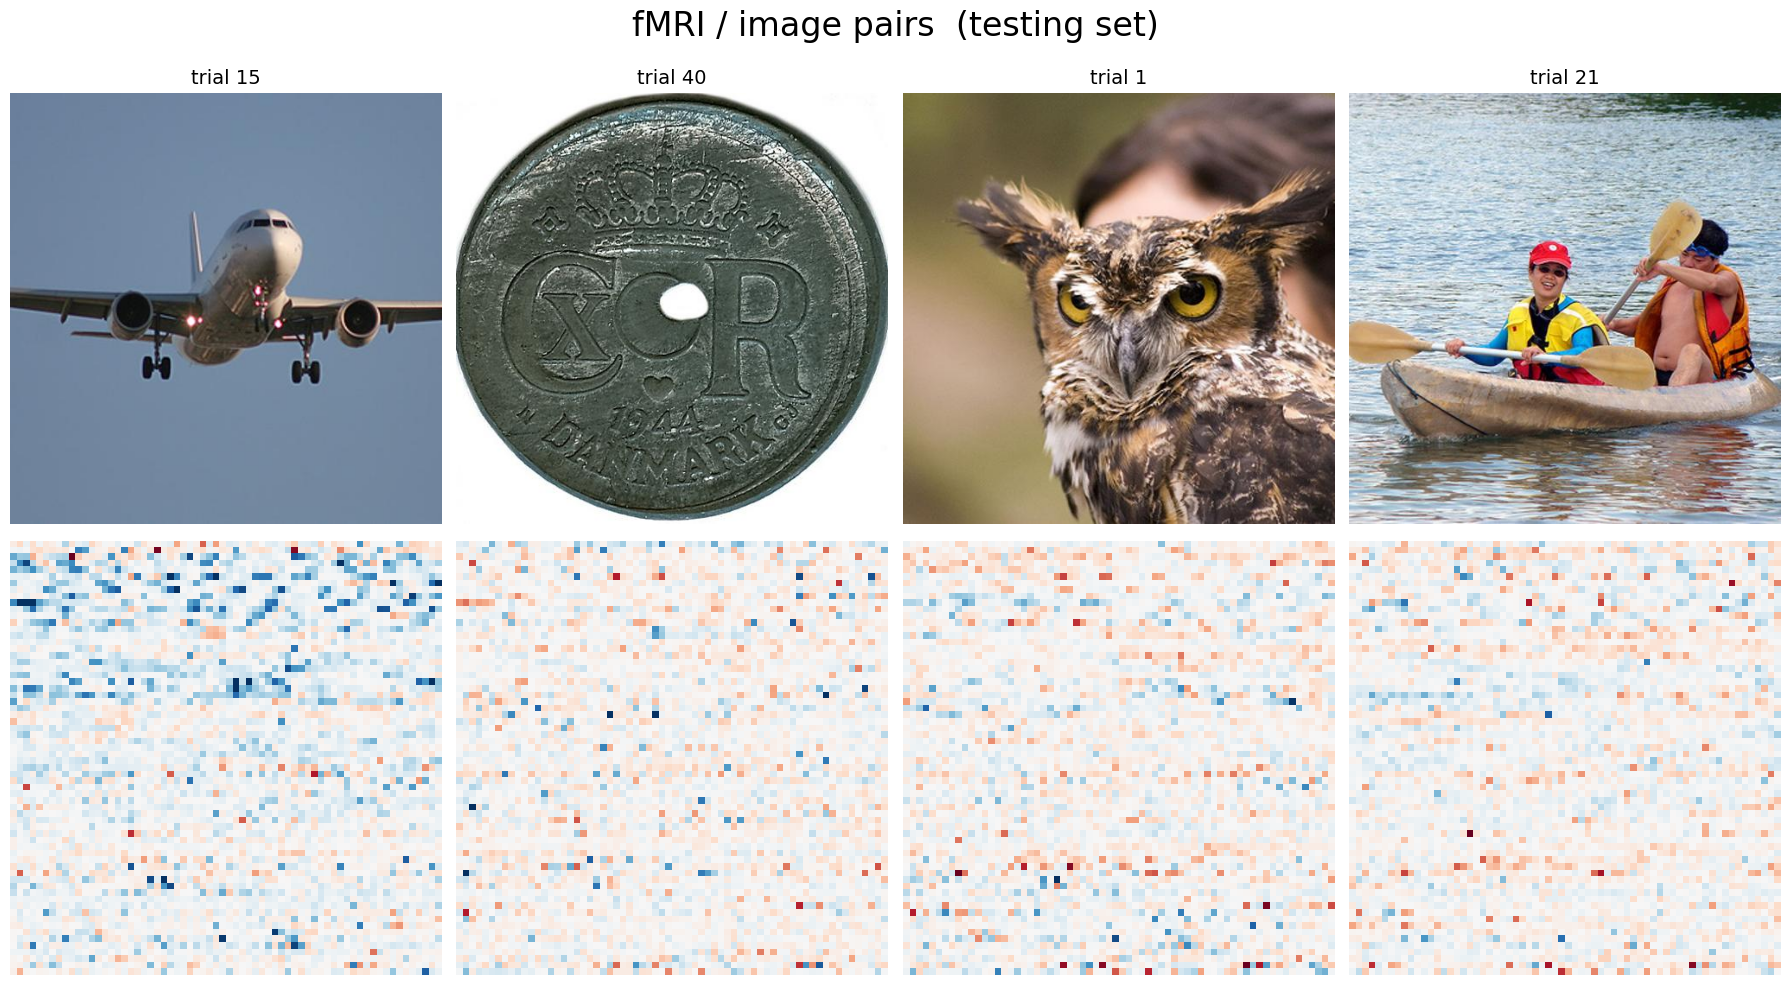

In [70]:
# Display some fMRI/image pairs
import random as rand
indices = rand.sample(range(len(pairs_train)), 4)
pairs_display = [pairs_train[i] for i in indices]

#training set
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('fMRI / image pairs  (training set) \n', fontsize=24)

for c, pair in enumerate(pairs_display):
  #img
  img = Image.open(pair['img_path']).convert('RGB')
  axes[0, c].imshow(img)
  axes[0, c].set_title(f'trial {pair["trial_idx"]}', fontsize=14)
  axes[0, c].axis('off')

  #fMRI
  fmri = pair['fmri']
  n = int(np.sqrt(fmri.shape[0]))
  fmri = fmri[:n*n]
  fmri = fmri.reshape(n, n)
  axes[1, c].imshow(fmri, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
  axes[1, c].set_title(' ', fontsize=14)
  axes[1, c].axis('off')

plt.tight_layout()
plt.show()

print("\n")
#testing set

indices = rand.sample(range(len(pairs_test)), 4)
pairs_display = [pairs_test[i] for i in indices]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('fMRI / image pairs  (testing set)\n', fontsize=24)

for c, pair in enumerate(pairs_display):
  #img
  img = Image.open(pair['img_path']).convert('RGB')
  axes[0, c].imshow(img)
  axes[0, c].set_title(f'trial {pair["trial_idx"]}', fontsize=14)
  axes[0, c].axis('off')

  #fMRI
  fmri = pair['fmri']
  n = int(np.sqrt(fmri.shape[0]))
  fmri = fmri[:n*n]
  fmri = fmri.reshape(n, n)
  axes[1, c].imshow(fmri, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
  axes[1, c].set_title(' ', fontsize=14)
  axes[1, c].axis('off')

plt.tight_layout()
plt.show()

#Stage 2: Encoder-Decoder

The architectures of the encoder and the decoder are based on the paper :

"From voxels to pixels and back: Self-supervision in
natural-image reconstruction from fMRI" (Beliy et al., 2019)

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as T
import torchvision.models as models

The training of the models require a gpu for acceptable computing time.

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

1. Creation of the training and testing datasets

2. Architecture

3. Loss functions

4. Training of the encoder

5. Training of the decoder